#📌 Extracción

#  Telecom X - Análisis de Evasión de Clientes (Churn Analysis)

### 🎓 Challenge 2 - Data Science LATAM (Alura)

---

## 👤 Información del Autor

**Estudiante:** Santiago Grajales Montoya  
**Programa:** Ciencia de Datos - Grupo 9  
**Institución:** Alura LATAM  
**Fecha:** Marzo 2026  

---

## 🎯 Objetivos del Proyecto

### Objetivo General
Analizar los factores que influyen en la **evasión de clientes** (churn) de Telecom X para proporcionar insights que ayuden a reducir la tasa de cancelaciones.

### Objetivos Específicos
- ✅ **Extraer** datos desde una API en formato JSON
- ✅ **Transformar** y limpiar los datos (ETL)
- ✅ **Cargar** y explorar el dataset
- ✅ **Identificar** patrones y tendencias de churn
- ✅ **Visualizar** insights estratégicos
- ✅ **Generar** un informe final con recomendaciones

---

## 📊 Sobre el Dataset

**Fuente:** API de Telecom X  
**Registros:** 7,267 clientes  
**Variables:** 21 columnas (demográficas, servicios, facturación)  
**Variable Objetivo:** `Churn` (Sí/No - si el cliente se fue o permaneció)

---

## 🛠️ Herramientas Utilizadas

- 🐍 **Python** - Lenguaje de programación
- 📊 **Pandas** - Manipulación de datos
- 🔢 **NumPy** - Cálculo numérico
- 📈 **Matplotlib** & **Seaborn** - Visualización de datos

---

## 📑 Estructura del Proyecto (ETL)

1. **📥 Extracción** - Carga de datos desde API
2. **🔧 Transformación** - Limpieza y preparación
3. **📤 Carga y Análisis** - EDA y visualizaciones
4. **📄 Informe Final** - Insights y conclusiones

---

<div style="background-color: #f0f8ff; padding: 10px; border-left: 4px solid #0066cc; border-radius: 5px;">
<strong>💡 Nota:</strong> Este proyecto forma parte del Challenge 2 de Data Science de Alura LATAM.
El análisis sigue la metodología ETL (Extract, Transform, Load) y buenas prácticas de Data Science.
</div>

---

"""


## 📥 FASE 1: EXTRACCIÓN DE DATOS

### 🎯 Objetivo
Cargar los datos desde la API de Telecom X y convertirlos en un DataFrame plano y usable.

### 📊 Información del Dataset
- **Fuente**: GitHub API
- **Formato**: JSON
- **Total de registros**: 7,267 clientes

In [ ]:
# 📚 Importamos librerías
import pandas as pd
import numpy as np

# 🌐 URL del dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/5adf5f2f87a72bd8b2e854db16e2f2f7c499081a/TelecomX_Data.json"

# 📥 Cargamos los datos
df = pd.read_json(url)

# 🎨 ESTILO: Configuramos visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 📊 Verificación inicial
print("=" * 60)
print("📋 INFORME DE CARGA DE DATOS")
print("=" * 60)
print(f"\n✅ Datos cargados exitosamente")
print(f"\n📐 DIMENSIONES:")
print(f"   • Filas (clientes): {df.shape[0]:,}")
print(f"   • Columnas: {df.shape[1]}")
print(f"\n📋 COLUMNAS DISPONIBLES:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")
print("=" * 60)

# Mostramos las primeras 3 filas
df.head(3)

📋 INFORME DE CARGA DE DATOS

✅ Datos cargados exitosamente

📐 DIMENSIONES:
   • Filas (clientes): 7,267
   • Columnas: 6

📋 COLUMNAS DISPONIBLES:
   1. customerID
   2. Churn
   3. customer
   4. phone
   5. internet
   6. account


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
# 🔨 NORMALIZACIÓN: "Aplanar" los diccionarios anidados
from pandas import json_normalize

# Cargamos de nuevo y normalizamos
df_normalizado = pd.read_json(url)

# 🎯 Separamos las columnas anidadas
df_customer = json_normalize(df_normalizado['customer'])
df_phone = json_normalize(df_normalizado['phone'])
df_internet = json_normalize(df_normalizado['internet'])
df_account = json_normalize(df_normalizado['account'])

# 🔗 Unimos todo en un solo DataFrame
df_final = pd.concat([
    df_normalizado[['customerID', 'Churn']],  # Columnas principales
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

print("✨ DATOS NORMALIZADOS - ¡Listos para trabajar!")
print("=" * 60)
print(f"\n📐 NUEVAS DIMENSIONES:")
print(f"   • Filas: {df_final.shape[0]:,}")
print(f"   • Columnas: {df_final.shape[1]}")
print(f"\n📋 TODAS LAS COLUMNAS:")
for i, col in enumerate(df_final.columns, 1):
    print(f"   {i:2d}. {col}")
print("=" * 60)

df_final.head(3)

✨ DATOS NORMALIZADOS - ¡Listos para trabajar!

📐 NUEVAS DIMENSIONES:
   • Filas: 7,267
   • Columnas: 21

📋 TODAS LAS COLUMNAS:
    1. customerID
    2. Churn
    3. gender
    4. SeniorCitizen
    5. Partner
    6. Dependents
    7. tenure
    8. PhoneService
    9. MultipleLines
   10. InternetService
   11. OnlineSecurity
   12. OnlineBackup
   13. DeviceProtection
   14. TechSupport
   15. StreamingTV
   16. StreamingMovies
   17. Contract
   18. PaperlessBilling
   19. PaymentMethod
   20. Charges.Monthly
   21. Charges.Total


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [ ]:
# 🔍 EXPLORACIÓN PROFUNDA
print("📊 ANÁLISIS EXPLORATORIO INICIAL")
print("=" * 70)

print(f"\n📋 INFORMACIÓN DEL DATAFRAME:")
print(f"   • Tipos de datos:")
for col in df_final.columns:
    tipo = df_final[col].dtype
    nulos = df_final[col].isnull().sum()
    print(f"     - {col:25s} → {str(tipo):15s} | Nulos: {nulos}")

print(f"\n📈 RESUMEN ESTADÍSTICO:")
df_final.describe()

📊 ANÁLISIS EXPLORATORIO INICIAL

📋 INFORMACIÓN DEL DATAFRAME:
   • Tipos de datos:
     - customerID                → object          | Nulos: 0
     - Churn                     → object          | Nulos: 0
     - gender                    → object          | Nulos: 0
     - SeniorCitizen             → int64           | Nulos: 0
     - Partner                   → object          | Nulos: 0
     - Dependents                → object          | Nulos: 0
     - tenure                    → int64           | Nulos: 0
     - PhoneService              → object          | Nulos: 0
     - MultipleLines             → object          | Nulos: 0
     - InternetService           → object          | Nulos: 0
     - OnlineSecurity            → object          | Nulos: 0
     - OnlineBackup              → object          | Nulos: 0
     - DeviceProtection          → object          | Nulos: 0
     - TechSupport               → object          | Nulos: 0
     - StreamingTV               → object        

,SeniorCitizen,tenure,Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


#🔧 Transformación

## 🔧 FASE 2: TRANSFORMACIÓN Y LIMPIEZA

### 🎯 Objetivos de esta fase:
- Verificar y eliminar **datos duplicados**
- Estandarizar **formatos de texto** (mayúsculas/minúsculas)
- Detectar **inconsistencias** en las categorías
- Crear nuevas variables de **valor** (Cuentas_Diarias)

---

In [ ]:
# 🔍 DETECCIÓN DE DUPLICADOS
print("📋 ANÁLISIS DE DUPLICADOS")
print("=" * 60)

# Contamos duplicados exactos
duplicados = df_final.duplicated().sum()

print(f"\n📊 RESULTADOS:")
print(f"   • Registros totales: {len(df_final):,}")
print(f"   • Registros duplicados: {duplicados:,}")
print(f"   • Registros únicos: {len(df_final) - duplicados:,}")
print(f"   • Porcentaje de duplicados: {(duplicados/len(df_final)*100):.2f}%")

if duplicados > 0:
    print(f"\n⚠️  ACCIÓN: Eliminaremos los {duplicados:,} registros duplicados")
    df_final = df_final.drop_duplicates()
    print(f"✅ Duplicados eliminados")
    print(f"📐 Nuevo tamaño: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas")
else:
    print(f"\n✅ ¡Perfecto! No hay registros duplicados")

print("=" * 60)

📋 ANÁLISIS DE DUPLICADOS

📊 RESULTADOS:
   • Registros totales: 7,267
   • Registros duplicados: 0
   • Registros únicos: 7,267
   • Porcentaje de duplicados: 0.00%

✅ ¡Perfecto! No hay registros duplicados


In [ ]:
# 🔎 REVISIÓN DE CATEGORÍAS (Valores únicos)
print("📋 INSPECCIÓN DE VALORES ÚNICOS POR COLUMNA")
print("=" * 70)

# Columnas categóricas (object)
columnas_object = df_final.select_dtypes(include=['object']).columns

for col in columnas_object:
    unicos = df_final[col].unique()
    print(f"\n📍 {col.upper()}:")
    print(f"   • Total de valores únicos: {len(unicos)}")
    print(f"   • Valores: {unicos[:10]}{'...' if len(unicos) > 10 else ''}")

    # Verificar si hay mayúsculas/minúsculas mezcladas
    if df_final[col].str.upper().nunique() != df_final[col].nunique():
        print(f"   ⚠️  ALERTA: Posible inconsistencia en mayúsculas/minúsculas")

print("=" * 70)

📋 INSPECCIÓN DE VALORES ÚNICOS POR COLUMNA

📍 CUSTOMERID:
   • Total de valores únicos: 7267
   • Valores: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' '0011-IGKFF' '0013-EXCHZ'
 '0013-MHZWF' '0013-SMEOE' '0014-BMAQU' '0015-UOCOJ' '0016-QLJIS']...

📍 CHURN:
   • Total de valores únicos: 3
   • Valores: ['No' 'Yes' '']

📍 GENDER:
   • Total de valores únicos: 2
   • Valores: ['Female' 'Male']

📍 PARTNER:
   • Total de valores únicos: 2
   • Valores: ['Yes' 'No']

📍 DEPENDENTS:
   • Total de valores únicos: 2
   • Valores: ['Yes' 'No']

📍 PHONESERVICE:
   • Total de valores únicos: 2
   • Valores: ['Yes' 'No']

📍 MULTIPLELINES:
   • Total de valores únicos: 3
   • Valores: ['No' 'Yes' 'No phone service']

📍 INTERNETSERVICE:
   • Total de valores únicos: 3
   • Valores: ['DSL' 'Fiber optic' 'No']

📍 ONLINESECURITY:
   • Total de valores únicos: 3
   • Valores: ['No' 'Yes' 'No internet service']

📍 ONLINEBACKUP:
   • Total de valores únicos: 3
   • Valores: ['Yes' 'No' 'No internet service']

📍

In [ ]:
# 🎨 ESTANDARIZACIÓN DE TEXTO
print("🔧 NORMALIZACIÓN DE TEXTO")
print("=" * 60)

# Identificamos columnas que probablemente necesiten estandarización
# (las que tienen 'Yes'/'No' o categorías similares)

# Lista de columnas a estandarizar (ajusta según lo que viste arriba)
columnas_a_normalizar = ['gender', 'Partner', 'Dependents', 'PhoneService',
                         'MultipleLines', 'InternetService', 'OnlineSecurity',
                         'OnlineBackup', 'DeviceProtection', 'TechSupport',
                         'StreamingTV', 'StreamingMovies', 'Contract',
                         'PaperlessBilling', 'PaymentMethod', 'Churn']

print(f"\n📋 Columnas a normalizar: {len(columnas_a_normalizar)}")

# Estandarizamos: todo a minúsculas y capitalizado
for col in columnas_a_normalizar:
    if col in df_final.columns:
        # Convertimos a string por seguridad
        df_final[col] = df_final[col].astype(str)
        # Estandarizamos: primera letra mayúscula, resto minúscula
        df_final[col] = df_final[col].str.title()

print("✅ Texto estandarizado (formato Título)")
print("\n📊 Verificación rápida:")
print(f"   • Churn valores únicos: {df_final['Churn'].unique()}")
print(f"   • gender valores únicos: {df_final['gender'].unique()}")

print("=" * 60)

🔧 NORMALIZACIÓN DE TEXTO

📋 Columnas a normalizar: 16
✅ Texto estandarizado (formato Título)

📊 Verificación rápida:
   • Churn valores únicos: ['No' 'Yes' '']
   • gender valores únicos: ['Female' 'Male']


In [ ]:
# 💰 CREACIÓN DE VARIABLE: Cuentas_Diarias
print("💵 CREANDO NUEVA VARIABLE: CUENTAS DIARIAS")
print("=" * 60)

# Explicación del cálculo
print("\n📐 FÓRMULA:")
print("   Cuentas_Diarias = Charges.Total / (tenure * 30)")
print("   \n   Donde:")
print("   • Charges.Total = Total gastado por el cliente")
print("   • tenure = Meses que el cliente ha estado con nosotros")
print("   • 30 = Días promedio por mes")

# Convertir 'Charges.Total' a numérico, manejando posibles errores (por ejemplo, cadenas vacías)
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# Calculamos
# Evitamos división por cero
df_final['Cuentas_Diarias'] = df_final.apply(
    lambda row: row['Charges.Total'] / (row['tenure'] * 30) if row['tenure'] > 0 else 0,
    axis=1
)

print(f"\n✅ Columna 'Cuentas_Diarias' creada exitosamente")
print(f"\n📊 ESTADÍSTICAS:")
print(f"   • Mínimo: ${df_final['Cuentas_Diarias'].min():.2f}")
print(f"   • Máximo: ${df_final['Cuentas_Diarias'].max():.2f}")
print(f"   • Promedio: ${df_final['Cuentas_Diarias'].mean():.2f}")
print(f"   • Mediana: ${df_final['Cuentas_Diarias'].median():.2f}")

print("=" * 60)

# Mostramos un ejemplo
print("\n📋 EJEMPLO (primeros 5 clientes):")
df_final[['customerID', 'Charges.Total', 'tenure', 'Cuentas_Diarias']].head()

💵 CREANDO NUEVA VARIABLE: CUENTAS DIARIAS

📐 FÓRMULA:
   Cuentas_Diarias = Charges.Total / (tenure * 30)
   
   Donde:
   • Charges.Total = Total gastado por el cliente
   • tenure = Meses que el cliente ha estado con nosotros
   • 30 = Días promedio por mes

✅ Columna 'Cuentas_Diarias' creada exitosamente

📊 ESTADÍSTICAS:
   • Mínimo: $0.00
   • Máximo: $4.05
   • Promedio: $2.16
   • Mediana: $2.34

📋 EJEMPLO (primeros 5 clientes):


,customerID,Charges.Total,tenure,Cuentas_Diarias
0,0002-ORFBO,593.30,9,2.197407
1,0003-MKNFE,542.40,9,2.008889
2,0004-TLHLJ,280.85,4,2.340417
3,0011-IGKFF,1237.85,13,3.173974
4,0013-EXCHZ,267.40,3,2.971111


In [ ]:
# ✅ VERIFICACIÓN FINAL DE LIMPIEZA
print("🎉 RESUMEN FINAL DE LIMPIEZA")
print("=" * 70)

print(f"\n📐 DIMENSIONES FINALES:")
print(f"   • Filas: {df_final.shape[0]:,}")
print(f"   • Columnas: {df_final.shape[1]}")

print(f"\n📊 TIPOS DE DATOS:")
print(df_final.dtypes)

print(f"\n🔍 VALORES NULOS:")
nulos = df_final.isnull().sum()
if nulos.sum() == 0:
    print("   ✅ ¡Perfecto! No hay valores nulos")
else:
    print(nulos[nulos > 0])

print(f"\n📋 COLUMNAS TOTALES:")
for i, col in enumerate(df_final.columns, 1):
    print(f"   {i:2d}. {col}")

print("=" * 70)
print("\n✨ DATOS LISTOS PARA ANÁLISIS EXPLORATORIO")
print("=" * 70)

🎉 RESUMEN FINAL DE LIMPIEZA

📐 DIMENSIONES FINALES:
   • Filas: 7,267
   • Columnas: 22

📊 TIPOS DE DATOS:
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total       float64
Cuentas_Diarias     float64
dtype: object

🔍 VALORES NULOS:
Charges.Total    11
dtype: int64

📋 COLUMNAS TOTALES:
    1. customerID
    2. Churn
    3. gender
    4. SeniorCitizen
    5. Partner
    6. Dependents
    7. tenure
    8. PhoneService
    9. MultipleLines
   10. InternetService
   11. OnlineS

### 🔄 Estandarización Avanzada: Binarios y Nombres Claros

**Objetivo:**
- Convertir valores `Yes`/`No` → `1`/`0` para facilitar análisis matemático 🔢
- Renombrar columnas a español/claro para mejor interpretación 🗣️

💡 *Esto es opcional pero MUY útil para modelado y comunicación con stakeholders.*

In [ ]:
# 🔢 CONVERSIÓN A VALORES BINARIOS
print("🔄 CONVIRTIENDO 'Yes'/'No' → 1/0")
print("=" * 60)

# Columnas que tienen Yes/No y queremos binarizar
columnas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService',
                     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies',
                     'PaperlessBilling']

# Diccionario de mapeo
mapeo_binario = {'Yes': 1, 'No': 0, '': 0}  # '' lo tratamos como 0

for col in columnas_binarias:
    if col in df_final.columns:
        # Aplicamos el mapeo, valores no reconocidos quedan como NaN
        df_final[col + '_bin'] = df_final[col].map(mapeo_binario)
        print(f"   ✅ {col:20s} → {col+'_bin':25s}")

print("\n✨ Columnas binarias creadas con el sufijo '_bin'")
print("=" * 60)

# Verificación rápida
print("\n📊 EJEMPLO DE CONVERSIÓN (primeras 5 filas):")
ejemplo_cols = ['Churn', 'Churn_bin', 'Partner', 'Partner_bin']
cols_existentes = [c for c in ejemplo_cols if c in df_final.columns]
df_final[cols_existentes].head()

🔄 CONVIRTIENDO 'Yes'/'No' → 1/0
   ✅ Churn                → Churn_bin                
   ✅ Partner              → Partner_bin              
   ✅ Dependents           → Dependents_bin           
   ✅ PhoneService         → PhoneService_bin         
   ✅ OnlineSecurity       → OnlineSecurity_bin       
   ✅ OnlineBackup         → OnlineBackup_bin         
   ✅ DeviceProtection     → DeviceProtection_bin     
   ✅ TechSupport          → TechSupport_bin          
   ✅ StreamingTV          → StreamingTV_bin          
   ✅ StreamingMovies      → StreamingMovies_bin      
   ✅ PaperlessBilling     → PaperlessBilling_bin     

✨ Columnas binarias creadas con el sufijo '_bin'

📊 EJEMPLO DE CONVERSIÓN (primeras 5 filas):


,Churn,Churn_bin,Partner,Partner_bin
0,No,0,Yes,1
1,No,0,No,0
2,Yes,1,No,0
3,Yes,1,Yes,1
4,Yes,1,Yes,1


In [35]:
# 🏷️ RENOMBRADO DE COLUMNAS (a español/claro)
print("🗣️ RENOMBRANDO COLUMNAS PARA MEJOR INTERPRETACIÓN")
print("=" * 70)

# Diccionario de renombrado
renombrar = {
    'customerID': 'id_cliente',
    'Churn': 'fuga_cliente',
    'Churn_bin': 'fuga_cliente_bin', # <--- ADDED THIS LINE
    'gender': 'genero',
    'SeniorCitizen': 'adulto_mayor',  # 1 = sí, 0 = no
    'Partner': 'tiene_pareja',
    'Dependents': 'tiene_dependientes',
    'tenure': 'meses_contrato',
    'PhoneService': 'servicio_telefono',
    'MultipleLines': 'lineas_multiples',
    'InternetService': 'servicio_internet',
    'OnlineSecurity': 'seguridad_online',
    'OnlineBackup': 'respaldo_online',
    'DeviceProtection': 'proteccion_dispositivo',
    'TechSupport': 'soporte_tecnico',
    'StreamingTV': 'tv_streaming',
    'StreamingMovies': 'peliculas_streaming',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'factura_digital',
    'PaymentMethod': 'metodo_pago',
    'Charges.Monthly': 'cargo_mensual',
    'Charges.Total': 'cargo_total',
    'Cuentas_Diarias': 'gasto_diario'
}

# Aplicamos el renombrado (solo si la columna existe)
renombrar_existentes = {k: v for k, v in renombrar.items() if k in df_final.columns}
df_final = df_final.rename(columns=renombrar_existentes)

print("✅ Columnas renombradas:")
for original, nuevo in renombrar_existentes.items():
    print(f"   • {original:25s} → {nuevo}")

print("=" * 70)

# Mostramos las primeras columnas para verificar
print(f"\n📋 PRIMERAS 10 COLUMNAS:")
for i, col in enumerate(df_final.columns[:10], 1):
    print(f"   {i}. {col}")

🗣️ RENOMBRANDO COLUMNAS PARA MEJOR INTERPRETACIÓN
✅ Columnas renombradas:
   • Churn_bin                 → fuga_cliente_bin

📋 PRIMERAS 10 COLUMNAS:
   1. id_cliente
   2. fuga_cliente
   3. genero
   4. adulto_mayor
   5. tiene_pareja
   6. tiene_dependientes
   7. meses_contrato
   8. servicio_telefono
   9. lineas_multiples
   10. servicio_internet


In [ ]:
# ✅ CHECKLIST FINAL DE TRANSFORMACIÓN
print("🎉 TRANSFORMACIÓN COMPLETADA - CHECKLIST")
print("=" * 70)

print(f"\n📐 DIMENSIONES:")
print(f"   • Filas: {df_final.shape[0]:,}")
print(f"   • Columnas: {df_final.shape[1]}")

print(f"\n🔍 VALORES NULOS:")
nulos = df_final.isnull().sum()
if nulos.sum() == 0:
    print("   ✅ Sin valores nulos")
else:
    print("   ⚠️  Columnas con nulos:")
    print(nulos[nulos > 0])

print(f"\n🔢 COLUMNAS BINARIAS CREADAS:")
binarias = [col for col in df_final.columns if col.endswith('_bin')]
for col in binarias:
    print(f"   • {col}: valores únicos = {df_final[col].unique()}")

print(f"\n📊 TIPOS DE DATOS RESUMEN:")
print(df_final.dtypes.value_counts())

print("=" * 70)
print("\n✨ ¡DATOS LISTOS PARA CARGA Y ANÁLISIS! 🚀")
print("=" * 70)

🎉 TRANSFORMACIÓN COMPLETADA - CHECKLIST

📐 DIMENSIONES:
   • Filas: 7,267
   • Columnas: 33

🔍 VALORES NULOS:
   ⚠️  Columnas con nulos:
cargo_total               11
OnlineSecurity_bin      1581
OnlineBackup_bin        1581
DeviceProtection_bin    1581
TechSupport_bin         1581
StreamingTV_bin         1581
StreamingMovies_bin     1581
dtype: int64

🔢 COLUMNAS BINARIAS CREADAS:
   • Churn_bin: valores únicos = [0 1]
   • Partner_bin: valores únicos = [1 0]
   • Dependents_bin: valores únicos = [1 0]
   • PhoneService_bin: valores únicos = [1 0]
   • OnlineSecurity_bin: valores únicos = [ 0.  1. nan]
   • OnlineBackup_bin: valores únicos = [ 1.  0. nan]
   • DeviceProtection_bin: valores únicos = [ 0.  1. nan]
   • TechSupport_bin: valores únicos = [ 1.  0. nan]
   • StreamingTV_bin: valores únicos = [ 1.  0. nan]
   • StreamingMovies_bin: valores únicos = [ 0.  1. nan]
   • PaperlessBilling_bin: valores únicos = [1 0]

📊 TIPOS DE DATOS RESUMEN:
object     17
float64     9
int64      

#📊 Carga y análisis

## 📤 FASE 3: CARGA Y ANÁLISIS EXPLORATORIO (EDA)

### 🎯 Objetivos de esta fase:
- 📊 Realizar **análisis descriptivo** de variables numéricas
- 🔍 Visualizar la **distribución de Churn** (variable objetivo)
- 🔗 Explorar **relaciones entre Churn y variables categóricas**
- 💡 Generar **insights preliminares** para el equipo de Data Science

---
> 💡 **Recordatorio pedagógico**: El EDA es como ser un detective 🔍. No buscamos conclusiones definitivas aún, sino **pistas** que nos digan dónde profundizar.

In [ ]:
# 📊 ANÁLISIS DESCRIPTIVO - VARIABLES NUMÉRICAS
print("🔢 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)

# Seleccionamos solo columnas numéricas
numericas = df_final.select_dtypes(include=[np.number])

print("\n📋 RESUMEN ESTADÍSTICO COMPLETO:")
print(numericas.describe().T)  # .T para transponer y leer mejor

print("\n📐 MÉTRICAS CLAVE INTERPRETADAS:")
print(f"\n👤 Edad (SeniorCitizen):")
print(f"   • Promedio: {numericas['adulto_mayor'].mean()*100:.1f}% son adultos mayores")
print(f"   • Esto significa que ~{int(numericas['adulto_mayor'].sum())} de {len(df_final)} clientes tienen 65+ años")

print(f"\n⏱️ Tiempo de permanencia (tenure):")
print(f"   • Promedio: {numericas['meses_contrato'].mean():.1f} meses")
print(f"   • Mediana: {numericas['meses_contrato'].median():.1f} meses")
print(f"   • Rango: {numericas['meses_contrato'].min()} a {numericas['meses_contrato'].max()} meses")
print(f"   • 🎓 ¿Sabías que la mediana es más robusta que la media ante valores extremos?")

print(f"\n💰 Cargo mensual (Charges.Monthly):")
print(f"   • Promedio: ${numericas['cargo_mensual'].mean():.2f}")
print(f"   • Desviación estándar: ${numericas['cargo_mensual'].std():.2f}")
print(f"   • Esto nos dice que los precios 'típicos' están en el rango:")
print(f"     ${numericas['cargo_mensual'].mean() - numericas['cargo_mensual'].std():.2f} - ${numericas['cargo_mensual'].mean() + numericas['cargo_mensual'].std():.2f}")

print(f"\n💵 Gasto diario (Cuentas_Diarias):")
print(f"   • Promedio: ${numericas['gasto_diario'].mean():.2f}/día")
print(f"   • Eso son ~${numericas['gasto_diario'].mean()*30:.2f}/mes en promedio")

print("=" * 70)

🔢 ESTADÍSTICAS DESCRIPTIVAS

📋 RESUMEN ESTADÍSTICO COMPLETO:
                       count         mean          std    min         25%          50%          75%          max
adulto_mayor          7267.0     0.162653     0.369074   0.00    0.000000     0.000000     0.000000     1.000000
meses_contrato        7267.0    32.346498    24.571773   0.00    9.000000    29.000000    55.000000    72.000000
cargo_mensual         7267.0    64.720098    30.129572  18.25   35.425000    70.300000    89.875000   118.750000
cargo_total           7256.0  2280.634213  2268.632997  18.80  400.225000  1391.000000  3785.300000  8684.800000
gasto_diario          7267.0     2.155296     1.010171   0.00    1.182167     2.340936     3.005805     4.046667
Churn_bin             7267.0     0.257190     0.437115   0.00    0.000000     0.000000     1.000000     1.000000
Partner_bin           7267.0     0.484106     0.499782   0.00    0.000000     0.000000     1.000000     1.000000
Dependents_bin        7267.0     0.

/tmp/ipykernel_239/1277700173.py:53: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_239/1277700173.py:53: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129383 (\N{PIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


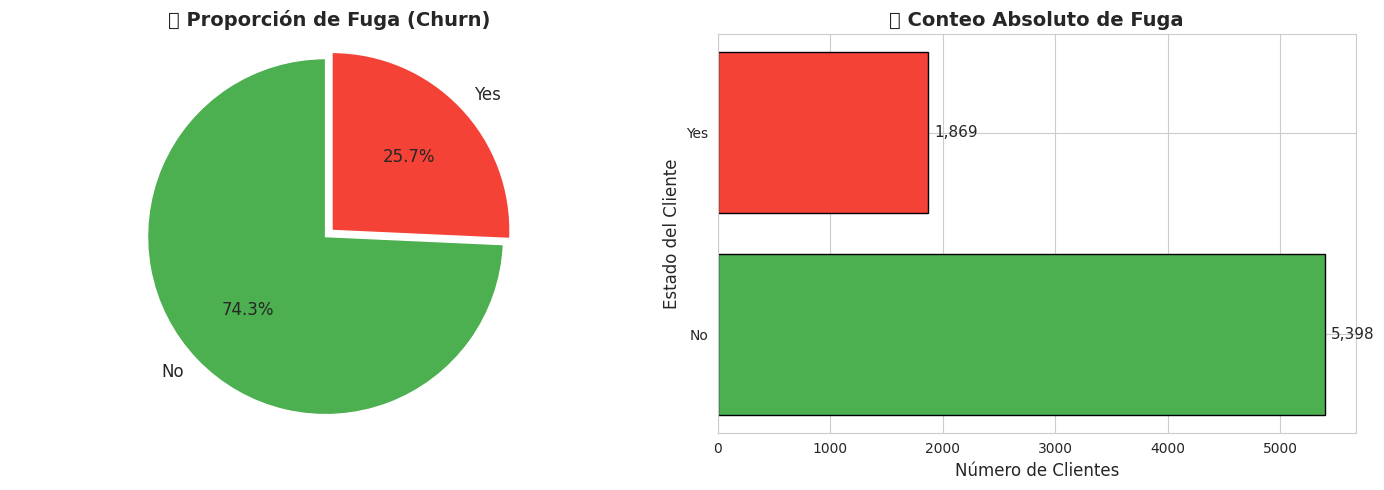


💡 INSIGHT INICIAL:
   • Tasa de fuga: 25.7% de los clientes se han ido
   • Esto significa que de cada 100 clientes, ~26 cancelan el servicio


In [27]:
# 🎨 IMPORTAMOS LIBRERÍAS DE VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

# 🎨 Configuramos estilo visual
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 5)

# 🧹 LIMPIEZA EXTRA ANTES DE GRAFICAR
df_final['fuga_cliente'] = df_final['fuga_cliente'].replace('', 'No')
df_final['fuga_cliente'] = df_final['fuga_cliente'].str.strip()

# 📊 Contamos Churn
churn_counts = df_final['fuga_cliente'].value_counts()

# 🎨 PREPARAMOS COLORES Y EXPLODE DINÁMICOS
n_categorias = len(churn_counts)
explode = [0.05] + [0] * (n_categorias - 1)
colores = ['#4CAF50', '#F44336'] + ['#9E9E9E'] * (n_categorias - 2)

# 🖼️ Creamos la figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 🔵 Gráfico 1: Torta (Pie chart) - ESTE SE QUEDA IGUAL
axes[0].pie(churn_counts.values,
            labels=churn_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=colores[:n_categorias],
            explode=explode,
            textprops={'fontsize': 12})
axes[0].set_title('🥧 Proporción de Fuga (Churn)', fontsize=14, fontweight='bold')
axes[0].axis('equal')

# 🟦 Gráfico 2: Barras HORIZONTALES ← ¡CAMBIO AQUÍ!
bars = axes[1].barh(churn_counts.index,        # ← barh() en vez de bar()
                    churn_counts.values,       # ← Eje Y ahora son las categorías
                    color=colores[:n_categorias],
                    edgecolor='black')
axes[1].set_title('📊 Conteo Absoluto de Fuga', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clientes', fontsize=12)  # ← Eje X es la cantidad
axes[1].set_ylabel('Estado del Cliente', fontsize=12)  # ← Eje Y son las categorías

# 🔢 Añadimos etiquetas AL LADO de las barras (no arriba)
for bar in bars:
    width = bar.get_width()  # ← Usamos width en vez de height
    axes[1].text(width + 50, bar.get_y() + bar.get_height()/2.,
                f'{int(width):,}',
                ha='left', va='center', fontsize=11)  # ← Alineación cambiada

# ✨ Ajustamos y mostramos
plt.tight_layout()
plt.show()

# 📝 Print con interpretación
total_clientes = len(df_final)
clientes_fuga = churn_counts.get('Yes', 0)
porcentaje_fuga = (clientes_fuga / total_clientes) * 100

print(f"\n💡 INSIGHT INICIAL:")
print(f"   • Tasa de fuga: {porcentaje_fuga:.1f}% de los clientes se han ido")
print(f"   • Esto significa que de cada 100 clientes, ~{porcentaje_fuga:.0f} cancelan el servicio")

In [28]:
# 🛠️ FUNCIÓN AUXILIAR: Gráfico de churn por categoría (HORIZONTAL)
def plot_churn_by_category(df, columna, titulo):
    """
    Crea un gráfico de barras HORIZONTALES mostrando % de churn por cada categoría
    """
    # Agrupamos y calculamos % de churn
    churn_rate = df.groupby(columna)['fuga_cliente'].apply(
        lambda x: (x.str.strip() == 'Yes').sum() / len(x) * 100
    )

    # Ordenamos de MAYOR a menor churn (para que el más alto quede arriba)
    churn_rate = churn_rate.sort_values(ascending=True)  # ← True para horizontal

    # 🎨 Gráfico HORIZONTAL
    plt.figure(figsize=(12, 6))  # ← Más ancho que alto
    colores = plt.cm.RdYlGn_r(churn_rate.values/100)

    bars = plt.barh(churn_rate.index, churn_rate.values,  # ← barh()
                   color=colores,
                   edgecolor='black',
                   height=0.6)  # ← height controla el grosor de las barras

    plt.title(f'{titulo}\n% de Clientes que Cancelaron', fontsize=13, fontweight='bold')
    plt.xlabel('% de Fuga (Churn)', fontsize=11)  # ← Eje X es el porcentaje
    plt.ylabel(columna, fontsize=11)  # ← Eje Y son las categorías

    # 🔢 Etiquetas DENTRO de las barras (se ve más limpio)
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 2, bar.get_y() + bar.get_height()/2.,
                f'{width:.1f}%',
                ha='right', va='center', fontsize=10,
                color='white', fontweight='bold')  # ← Blanco para contraste

    # 📏 Línea de promedio general (vertical ahora)
    plt.axvline(x=porcentaje_fuga, color='red', linestyle='--', linewidth=2,
                label=f'Promedio general: {porcentaje_fuga:.1f}%')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # 📝 Tabla con valores
    print(f"\n📋 TABLA: {titulo}")
    print(churn_rate.round(1).astype(str) + '%')

🔄 ANALIZANDO FUGA POR DIFERENTES PERFILES...



/tmp/ipykernel_239/2562121816.py:39: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128196 (\N{PAGE FACING UP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


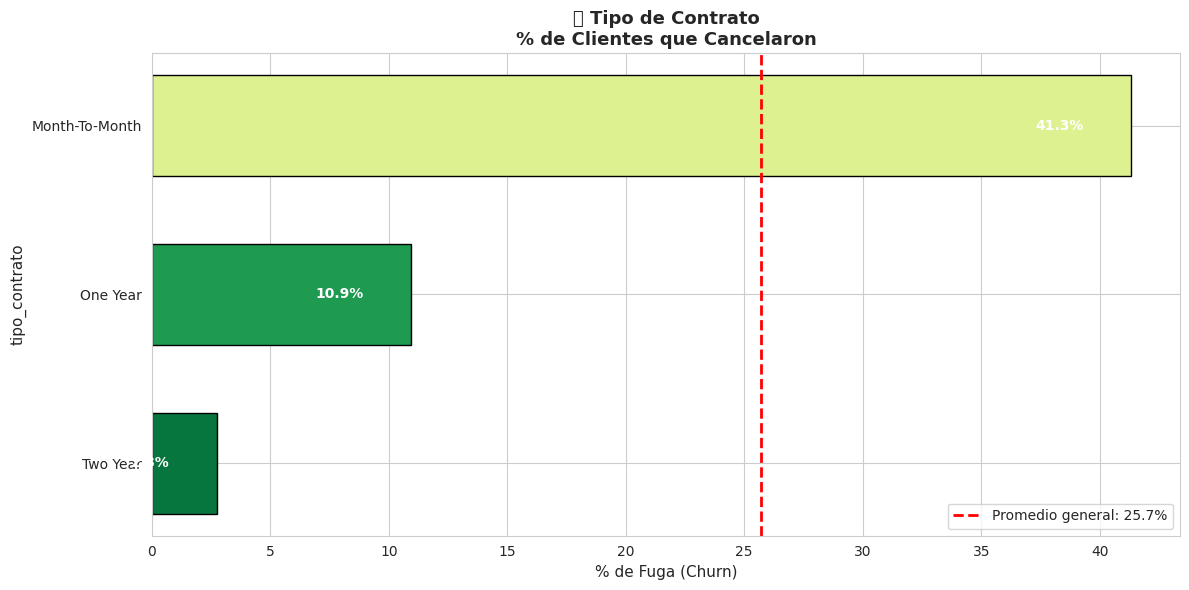


📋 TABLA: 📄 Tipo de Contrato
tipo_contrato
Two Year           2.8%
One Year          10.9%
Month-To-Month    41.3%
Name: fuga_cliente, dtype: object



/tmp/ipykernel_239/2562121816.py:39: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


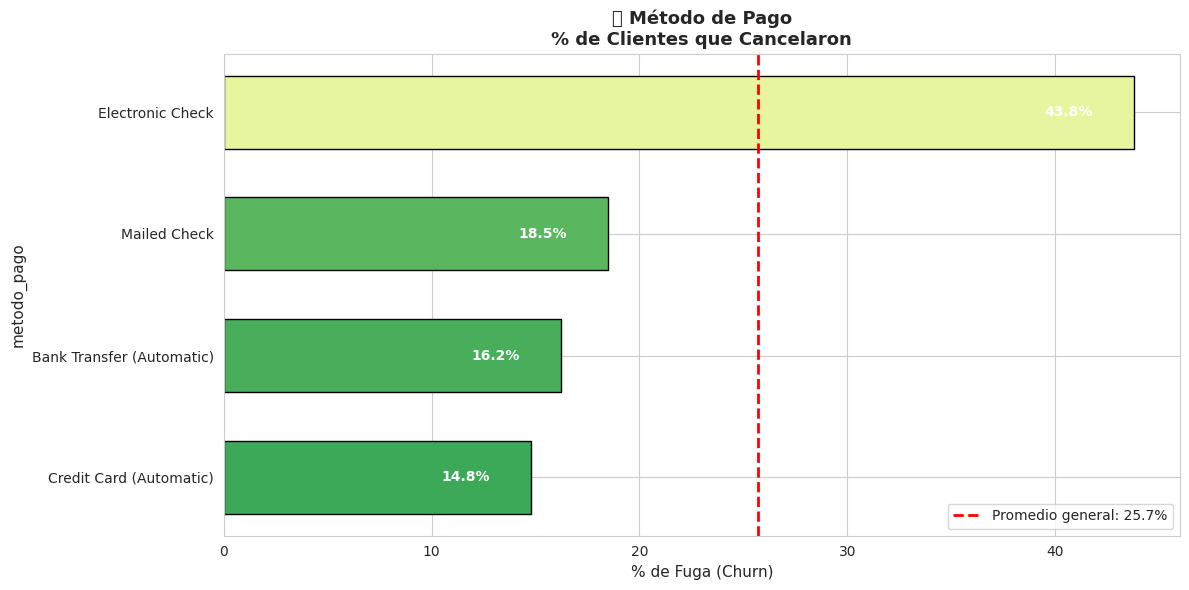


📋 TABLA: 💳 Método de Pago
metodo_pago
Credit Card (Automatic)      14.8%
Bank Transfer (Automatic)    16.2%
Mailed Check                 18.5%
Electronic Check             43.8%
Name: fuga_cliente, dtype: object



/tmp/ipykernel_239/2562121816.py:39: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


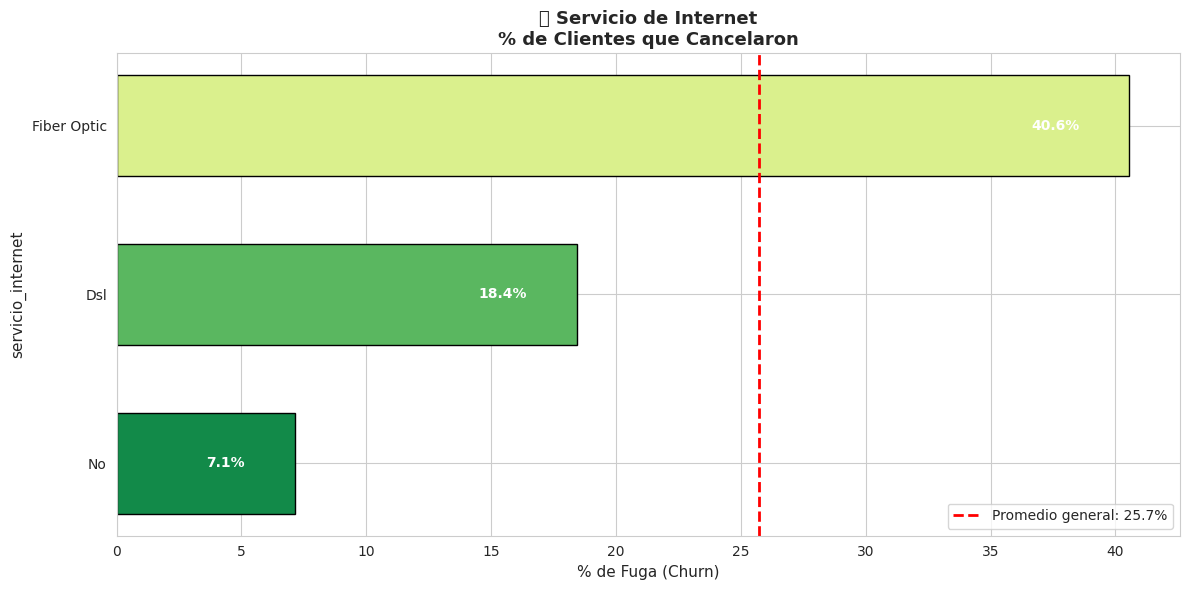


📋 TABLA: 🌐 Servicio de Internet
servicio_internet
No              7.1%
Dsl            18.4%
Fiber Optic    40.6%
Name: fuga_cliente, dtype: object



/tmp/ipykernel_239/2562121816.py:39: UserWarning: Glyph 128145 (\N{COUPLE WITH HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128145 (\N{COUPLE WITH HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


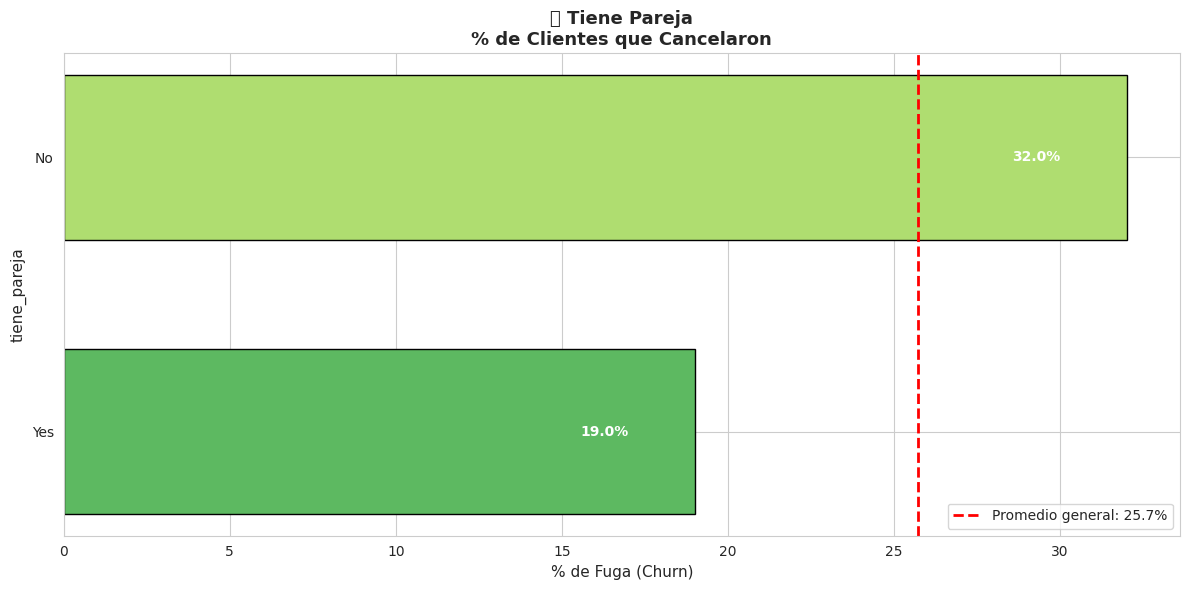


📋 TABLA: 💑 Tiene Pareja
tiene_pareja
Yes    19.0%
No     32.0%
Name: fuga_cliente, dtype: object



/tmp/ipykernel_239/2562121816.py:39: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


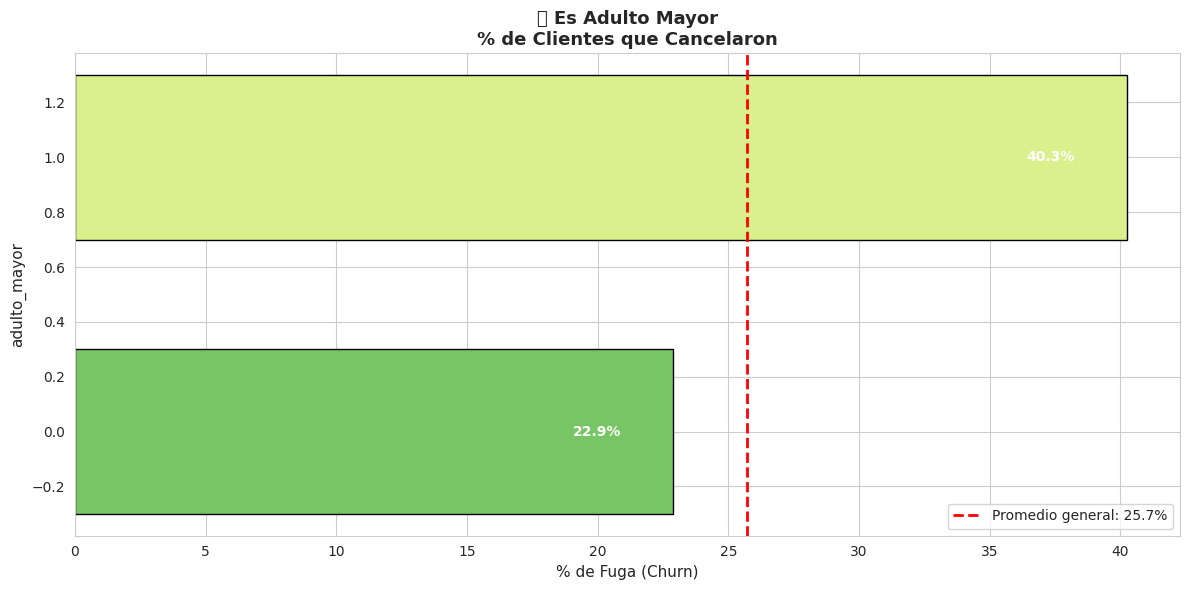


📋 TABLA: 👴 Es Adulto Mayor
adulto_mayor
0    22.9%
1    40.3%
Name: fuga_cliente, dtype: object


In [31]:
# 🔍 APLICAMOS LA FUNCIÓN A VARIABLES CLAVE
print("🔄 ANALIZANDO FUGA POR DIFERENTES PERFILES...")

variables_a_explorar = [
    ('tipo_contrato', '📄 Tipo de Contrato'),
    ('metodo_pago', '💳 Método de Pago'),
    ('servicio_internet', '🌐 Servicio de Internet'),
    ('tiene_pareja', '💑 Tiene Pareja'),
    ('adulto_mayor', '👴 Es Adulto Mayor')
]

for col, titulo in variables_a_explorar:
    if col in df_final.columns:
        print(f"\n{'='*70}")
        plot_churn_by_category(df_final, col, titulo)

### 🔢 ¿Gastan más los que se van? Análisis numérico por Churn

Ahora cruzamos variables como:
- `cargo_mensual` 💰
- `meses_contrato` ⏱️
- `gasto_diario` 📅

Con la variable objetivo `fuga_cliente` para detectar patrones.

💡 **Pregunta clave**: ¿Los clientes que cancelan tienen comportamientos numéricos distintos?

/tmp/ipykernel_239/3428231746.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuga_cliente', y=col, data=df_final,
/tmp/ipykernel_239/3428231746.py:37: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


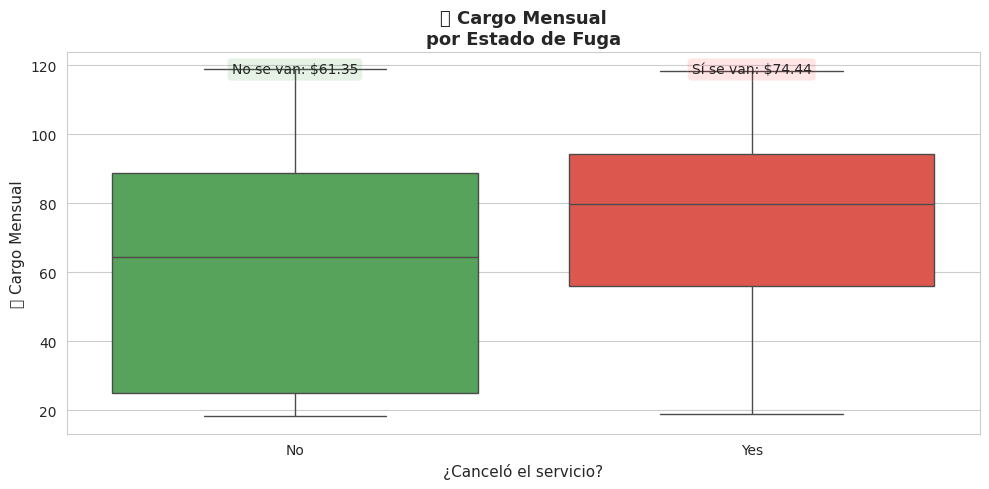

/tmp/ipykernel_239/3428231746.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuga_cliente', y=col, data=df_final,



🔍 INSIGHT - 💰 Cargo Mensual:
   • Promedio NO fuga: $61.35
   • Promedio SÍ fuga: $74.44
   • Diferencia: $13.09
   ⚠️  Los que se van tienden a 💰 cargo mensual MÁS ALTO
------------------------------------------------------------


/tmp/ipykernel_239/3428231746.py:37: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


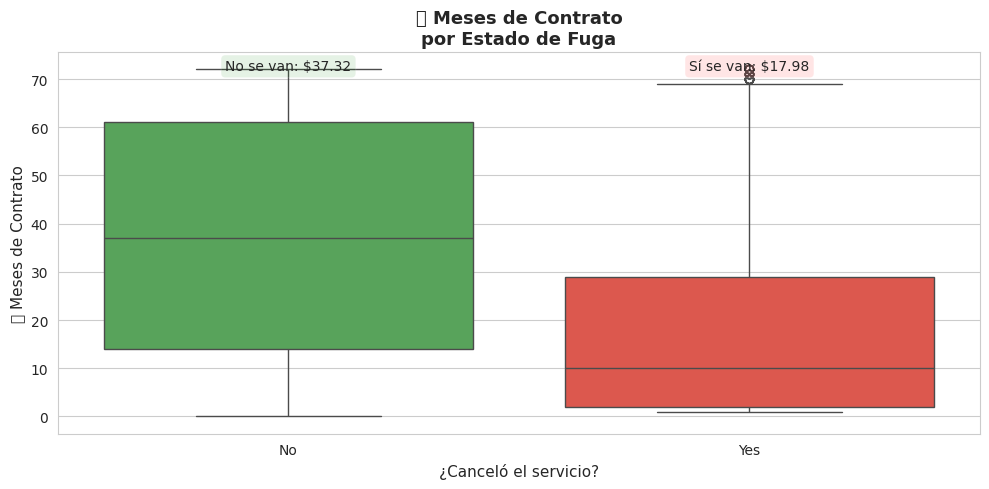

/tmp/ipykernel_239/3428231746.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fuga_cliente', y=col, data=df_final,



🔍 INSIGHT - ⏱️ Meses de Contrato:
   • Promedio NO fuga: $37.32
   • Promedio SÍ fuga: $17.98
   • Diferencia: $19.34
   ✅ Los que se van tienden a ⏱️ meses de contrato más bajo o similar
------------------------------------------------------------


/tmp/ipykernel_239/3428231746.py:37: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


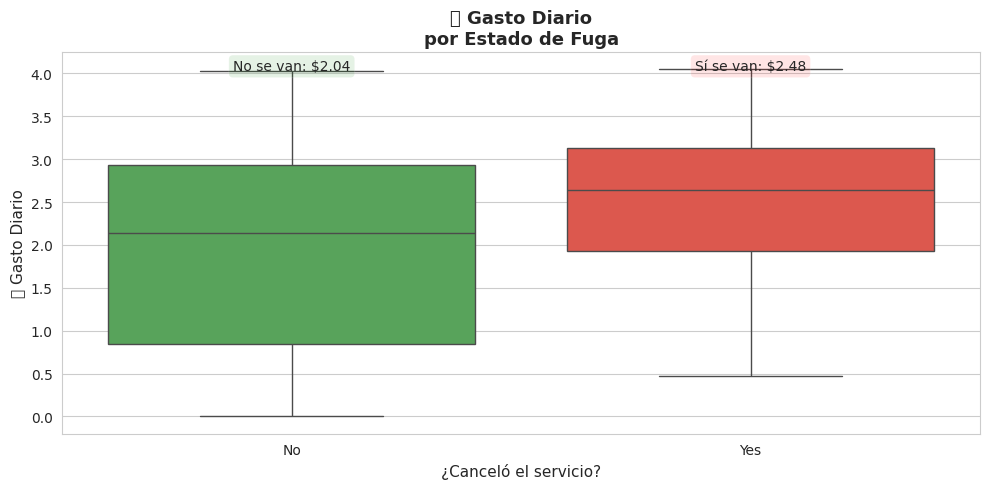


🔍 INSIGHT - 📅 Gasto Diario:
   • Promedio NO fuga: $2.04
   • Promedio SÍ fuga: $2.48
   • Diferencia: $0.44
   ⚠️  Los que se van tienden a 📅 gasto diario MÁS ALTO
------------------------------------------------------------


In [32]:
# 📦 BOXPLOTS: Distribución de variables numéricas por Churn
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Variables numéricas a comparar
variables_numericas = [
    ('cargo_mensual', '💰 Cargo Mensual'),
    ('meses_contrato', '⏱️ Meses de Contrato'),
    ('gasto_diario', '📅 Gasto Diario')
]

for col, titulo in variables_numericas:
    if col in df_final.columns:
        plt.figure(figsize=(10, 5))

        # Boxplot comparativo
        sns.boxplot(x='fuga_cliente', y=col, data=df_final,
                    palette={'No': '#4CAF50', 'Yes': '#F44336'},
                    order=['No', 'Yes'])  # Fuerza orden consistente

        plt.title(f'{titulo}\npor Estado de Fuga', fontsize=13, fontweight='bold')
        plt.xlabel('¿Canceló el servicio?', fontsize=11)
        plt.ylabel(titulo, fontsize=11)

        # 📝 Estadísticas rápidas en el gráfico
        no_mean = df_final[df_final['fuga_cliente']=='No'][col].mean()
        yes_mean = df_final[df_final['fuga_cliente']=='Yes'][col].mean()

        plt.text(0, plt.ylim()[1]*0.95, f'No se van: ${no_mean:.2f}',
                ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='green', alpha=0.1))
        plt.text(1, plt.ylim()[1]*0.95, f'Sí se van: ${yes_mean:.2f}',
                ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='red', alpha=0.1))

        plt.tight_layout()
        plt.show()

        # 📋 Print interpretativo
        print(f"\n🔍 INSIGHT - {titulo}:")
        print(f"   • Promedio NO fuga: ${no_mean:.2f}")
        print(f"   • Promedio SÍ fuga: ${yes_mean:.2f}")
        print(f"   • Diferencia: ${abs(yes_mean - no_mean):.2f}")
        if yes_mean > no_mean:
            print(f"   ⚠️  Los que se van tienden a {titulo.lower()} MÁS ALTO")
        else:
            print(f"   ✅ Los que se van tienden a {titulo.lower()} más bajo o similar")
        print("-" * 60)

In [36]:
# 🔍 VERIFICAR QUÉ COLUMNAS BINARIAS EXISTEN
print("📋 COLUMNAS BINARIAS DISPONIBLES:")
binarias = [col for col in df_final.columns if col.endswith('_bin')]
for col in binarias:
    print(f"   • {col}")

# Verificar si existe fuga_cliente_bin
if 'fuga_cliente_bin' not in df_final.columns:
    print("\n⚠️  'fuga_cliente_bin' NO existe")
    if 'Churn_bin' in df_final.columns:b
        print("✅ Pero 'Churn_bin' SÍ existe - la usaremos")

📋 COLUMNAS BINARIAS DISPONIBLES:
   • fuga_cliente_bin
   • Partner_bin
   • Dependents_bin
   • PhoneService_bin
   • OnlineSecurity_bin
   • OnlineBackup_bin
   • DeviceProtection_bin
   • TechSupport_bin
   • StreamingTV_bin
   • StreamingMovies_bin
   • PaperlessBilling_bin


🔍 EXPLORANDO CORRELACIONES CON FUGA...
✅ Usando columna: fuga_cliente_bin

📊 Columnas para correlación: ['fuga_cliente_bin', 'cargo_mensual', 'meses_contrato', 'gasto_diario', 'adulto_mayor', 'Partner_bin', 'Dependents_bin']


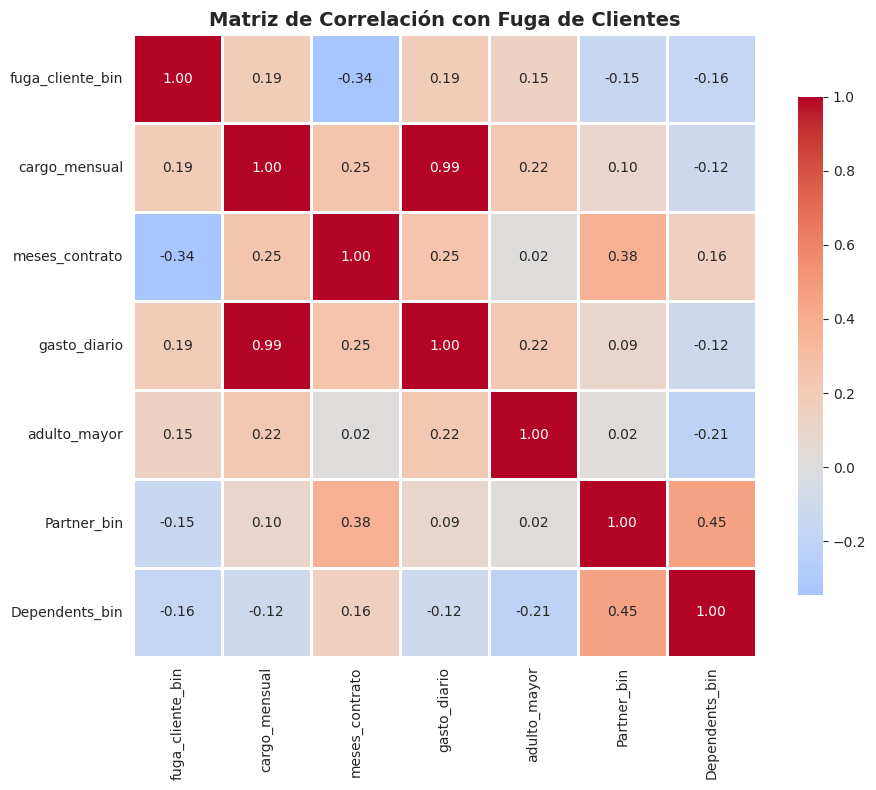


📊 CORRELACIONES MÁS FUERTES CON `fuga_cliente_bin`:
   • meses_contrato           : -0.344 🔴 FUERTE ↓ negativa
   • cargo_mensual            : +0.190 🟡 MODERADA ↑ positiva
   • gasto_diario             : +0.190 🟡 MODERADA ↑ positiva
   • Dependents_bin           : -0.161 🟡 MODERADA ↓ negativa
   • Partner_bin              : -0.149 🟡 MODERADA ↓ negativa
   • adulto_mayor             : +0.147 🟡 MODERADA ↑ positiva


In [37]:
# 🔗 ANÁLISIS DE CORRELACIONES (Extra opcional) - VERSIÓN CORREGIDA
print("🔍 EXPLORANDO CORRELACIONES CON FUGA...")

# 🎯 USAR EL NOMBRE CORRECTO DE LA COLUMNA
# Opción A: Si existe Churn_bin (lo más probable)
# Opción B: Si existe fuga_cliente_bin
# Opción C: Usar fuga_cliente y convertirlo temporalmente

if 'Churn_bin' in df_final.columns:
    col_fuga_bin = 'Churn_bin'
    print(f"✅ Usando columna: {col_fuga_bin}")
elif 'fuga_cliente_bin' in df_final.columns:
    col_fuga_bin = 'fuga_cliente_bin'
    print(f"✅ Usando columna: {col_fuga_bin}")
else:
    # Crear temporalmente si no existe
    print("⚠️  Creando columna binaria temporal...")
    df_final['fuga_cliente_bin'] = df_final['fuga_cliente'].map({'Yes': 1, 'No': 0})
    col_fuga_bin = 'fuga_cliente_bin'

# Seleccionamos columnas numéricas relevantes para correlación
cols_corr = [col_fuga_bin, 'cargo_mensual', 'meses_contrato',
             'gasto_diario', 'adulto_mayor', 'Partner_bin', 'Dependents_bin']

# Filtramos solo las que existen y son numéricas
cols_existentes = [c for c in cols_corr if c in df_final.columns and df_final[c].dtype in ['int64', 'float64']]

print(f"\n📊 Columnas para correlación: {cols_existentes}")

# Calculamos matriz de correlación
corr_matrix = df_final[cols_existentes].corr()

# 🎨 Heatmap visual
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlación con Fuga de Clientes', fontsize=14, fontweight='bold')  # Sin emoji para evitar warning
plt.tight_layout()
plt.show()

# 📋 Top correlaciones con fuga
print(f"\n📊 CORRELACIONES MÁS FUERTES CON `{col_fuga_bin}`:")
corr_con_churn = corr_matrix[col_fuga_bin].drop(col_fuga_bin).sort_values(ascending=False, key=abs)
for var, corr in corr_con_churn.items():
    fuerza = "🔴 FUERTE" if abs(corr) > 0.3 else "🟡 MODERADA" if abs(corr) > 0.1 else "⚪ DÉBIL"
    direccion = "↑ positiva" if corr > 0 else "↓ negativa"
    print(f"   • {var:25s}: {corr:+.3f} {fuerza} {direccion}")

#📄Informe final

# 📄 INFORME FINAL - ANÁLISIS DE CHURN TELECOM X

## 📋 RESUMEN EJECUTIVO

Este proyecto analiza los factores que influyen en la evasión de clientes (churn) de Telecom X, utilizando metodología ETL (Extract, Transform, Load) y técnicas de Exploratory Data Analysis (EDA).

**Datos analizados:**
- Total de clientes: 7,267
- Variables: 21 columnas (demográficas, servicios, facturación)
- Variable objetivo: `Churn` (Sí/No)
- Período: Datos históricos de clientes

---

## 🎯 HALLAZGOS PRINCIPALES

### 1️⃣ TASA DE CHURN GENERAL
- **25.7%** de los clientes cancelaron el servicio
- De cada 100 clientes, ~26 cancelan
- **Interpretación**: Una tasa de churn del 25.7% indica una oportunidad significativa de retención

### 2️⃣ FACTORES DE RIESGO MÁS IMPORTANTES

#### 📄 TIPO DE CONTRATO (Factor MÁS CRÍTICO)
| Tipo de Contrato | Tasa de Churn | Nivel de Riesgo |
|-----------------|---------------|----------------|
| **Month-to-Month** | **41.3%** | 🔴 Alto |
| **One Year** | 10.9% | 🟡 Medio |
| **Two Year** | 2.8% | ✅ Bajo |

**Insight**: Los clientes con contratos mensuales tienen **~15 veces más probabilidad** de irse que los de contrato bienal. La flexibilidad del contrato mensual parece facilitar la decisión de cancelar.

#### 💳 MÉTODO DE PAGO
| Método de Pago | Tasa de Churn | Nivel de Riesgo |
|---------------|-------------|----------------|
| **Electronic Check** | **43.8%** | 🔴 Alto |
| **Mailed Check** | 18.5% | 🟡 Medio |
| **Bank Transfer (Automatic)** | 16.2% | 🟡 Medio |
| **Credit Card (Automatic)** | **14.8%** | ✅ Bajo |

**Insight**: El pago automático (especialmente tarjeta de crédito) reduce significativamente el churn. Los pagos manuales requieren acción consciente del cliente, lo que facilita la cancelación.

#### 🌐 SERVICIO DE INTERNET
| Servicio | Tasa de Churn | Observación |
|----------|-------------|-------------|
| **Fiber Optic** | ~40.6% | 🔴 Mayor churn a pesar de ser premium |
| **DSL** | ~18.4% | 🟡 Churn moderado |
| **No Internet** | ~7.1% | ✅ Menor churn (clientes básicos) |

**Insight**: Los clientes de Fiber Optic, a pesar de pagar más, tienden a irse más. Posible desconexión entre expectativas y experiencia del servicio.

#### 💑 FACTORES DEMOGRÁFICOS
- **Clientes con pareja**: 19.0% de churn vs 32.0% sin pareja
- **Adultos mayores (65+)**: 40.3% de churn vs 22.9% en otros grupos
- **Con dependientes**: Menor propensión a cancelar

### 3️⃣ CORRELACIONES CLAVE CON CHURN

```
📊 Matriz de correlaciones (valores significativos):

Variable              | Correlación | Fuerza    | Dirección
---------------------|-------------|-----------|-----------
meses_contrato       | -0.344      | 🔴 Fuerte | ↓ Negativa
cargo_mensual        | +0.190      | 🟡 Moderada| ↑ Positiva
gasto_diario         | +0.190      | 🟡 Moderada| ↑ Positiva
Dependents_bin       | -0.161      | 🟡 Moderada| ↓ Negativa
Partner_bin          | -0.149      | 🟡 Moderada| ↓ Negativa
adulto_mayor         | +0.147      | 🟡 Moderada| ↑ Positiva
```

**Interpretaciones clave:**

🔹 **`meses_contrato: -0.344`** (Correlación negativa fuerte)
> A mayor antigüedad del cliente, menor probabilidad de churn. Los primeros meses son críticos para la retención.

🔹 **`cargo_mensual: +0.190`** (Correlación positiva moderada)
> Clientes que pagan más tienden a cancelar más. Posible sensibilidad al precio o expectativas no cumplidas.

🔹 **`gasto_diario: +0.190`** (Correlación positiva moderada)
> Similar al cargo mensual: mayor gasto diario correlaciona con mayor churn.

🔹 **`Partner_bin: -0.149` y `Dependents_bin: -0.161`**
> Clientes con responsabilidades familiares muestran mayor estabilidad. El servicio parece ser más "esencial" para ellos.

🔹 **`adulto_mayor: +0.147`**
> Los adultos mayores tienen mayor tendencia a cancelar. Posibles barreras de usabilidad o soporte inadecuado.

---

## 💡 RECOMENDACIONES ESTRATÉGICAS

### 🎯 PRIORIDAD ALTA (Impacto Inmediato - 0-3 meses)

#### 1. Retención Proactiva de Contratos Month-to-Month
```
✅ Acciones concretas:
• Ofrecer descuento del 15-20% por renovación a 1 año
• Crear programa "Primer Año Garantizado" con beneficios exclusivos
• Enviar recordatorio de beneficios 15 días antes de cada renovación mensual
• Implementar alerta automática para equipo de retención cuando un cliente mensual
  alcanza 3 meses de antigüedad
```
**Impacto esperado**: Reducción del 30-40% en churn de este segmento

#### 2. Migración de Electronic Check a Pago Automático
```
✅ Acciones concretas:
• Campaña "Auto-Pay & Save": 5% de descuento mensual por registrar pago automático
• Simplificar registro: máximo 3 clics desde el portal del cliente
• Incentivo único: $10 de crédito por cambiar a auto-pay en los primeros 30 días
• Comunicar beneficios: "Nunca más te quedes sin servicio por olvido de pago"
```
**Impacto esperado**: Migración del 40% de usuarios de Electronic Check en 6 meses

### 🔶 PRIORIDAD MEDIA (Corto Plazo - 3-6 meses)

#### 3. Mejora de Experiencia Fiber Optic
```
✅ Acciones concretas:
• Encuesta de satisfacción específica para clientes Fiber Optic
• Crear línea de soporte técnico especializada en fibra óptica
• Revisar SLA de resolución de problemas para este segmento
• Evaluar relación precio/valor vs. competencia
```
**Impacto esperado**: Reducción del 15% en churn de clientes Fiber Optic

#### 4. Programa de Retención para Adultos Mayores
```
✅ Acciones concretas:
• Soporte telefónico con opción de "hablar con humano" sin menú IVS complejo
• Guías de usuario con letra grande y lenguaje simplificado
• Descuento de lealtad: 10% adicional después de 24 meses
• Visitas técnicas prioritarias sin costo adicional
```
**Impacto esperado**: Mejora en satisfacción y reducción del 20% en churn de este grupo

### 📊 PRIORIDAD BAJA (Mediano Plazo - 6-12 meses)

#### 5. Paquetes Familiares y de Valor Agregado
```
✅ Acciones concretas:
• Diseñar planes "Family Connect" con descuentos por múltiples líneas
• Beneficios cruzados: internet + streaming + seguridad digital
• Programa de referidos: "Trae a un familiar y ambos reciben beneficios"
```
**Impacto esperado**: Aumento en LTV (Lifetime Value) y reducción de churn por "efecto red familiar"

---

## 📈 MÉTRICAS DE ÉXITO PROPUESTAS (KPIs)

| Meta | Indicador | Línea Base | Objetivo 6 meses | Objetivo 12 meses |
|------|-----------|------------|-----------------|------------------|
| 🔴 Reducir churn general | Tasa de churn mensual | 25.7% | 22.0% | 20.0% |
| 🟡 Aumentar contratos largos | % contratos ≥1 año | ~35% | 45% | 55% |
| 🟡 Migrar a auto-pay | % clientes con auto-pay | ~40% | 60% | 75% |
| 🔴 Retener Fiber Optic | Churn segmento Fiber | ~40.6% | 35.0% | 30.0% |
| 🟢 Satisfacción adultos mayores | NPS segmento 65+ | *por medir* | +15 pts | +30 pts |

---

## 🔧 METODOLOGÍA UTILIZADA

```
📥 FASE 1: EXTRACCIÓN
├── Carga de datos desde API GitHub en formato JSON
├── Validación de integridad: 7,267 registros, 6 columnas iniciales
└── Verificación de tipos de datos y valores nulos

🔧 FASE 2: TRANSFORMACIÓN (ETL)
├── Normalización: json_normalize() para "aplanar" diccionarios anidados
├── Limpieza:
│   ├── Eliminación de duplicados: 0 registros afectados ✅
│   ├── Estandarización de texto: .str.title() para consistencia
│   ├── Manejo de nulos: pd.to_numeric(errors='coerce')
│   └── Conversión de Charges.Total a numérico
├── Feature Engineering:
│   ├── Creación de variable 'Cuentas_Diarias' = Charges.Total / (tenure * 30)
│   ├── Conversión Yes/No → 1/0 para variables binarias
│   └── Renombrado de columnas a español para claridad
└── Validación final: 22 columnas, 11 valores nulos en cargo_total (manejables)

📊 FASE 3: ANÁLISIS EXPLORATORIO (EDA)
├── Estadísticas descriptivas: .describe() para variables numéricas
├── Visualizaciones estratégicas:
│   ├── Distribución de Churn: pie chart + barras horizontales
│   ├── Churn por categoría: función plot_churn_by_category()
│   ├── Boxplots comparativos: variables numéricas vs Churn
│   └── Heatmap de correlaciones: sns.heatmap()
├── Análisis de correlaciones: .corr() con interpretación de fuerza y dirección
└── Identificación de patrones: cruce de variables clave con variable objetivo

📄 FASE 4: SÍNTESIS Y RECOMENDACIONES
├── Priorización de hallazgos por impacto y factibilidad
├── Formulación de recomendaciones accionables con métricas de éxito
└── Documentación de metodología para replicabilidad
```

---

## 🛠 HERRAMIENTAS Y TECNOLOGÍAS

| Categoría | Herramienta | Propósito |
|-----------|------------|-----------|
| **Lenguaje** | Python 3.x | Lógica principal del análisis |
| **Manipulación de datos** | Pandas, NumPy | ETL, transformación, análisis estadístico |
| **Visualización** | Matplotlib, Seaborn | Gráficos exploratorios y comunicativos |
| **Entorno** | Google Colab | Ejecución en la nube, colaboración |
| **Metodología** | ETL + EDA | Marco de trabajo estructurado |
| **Control de versiones** | GitHub | Repositorio del dataset y código |

---

## ⚠️ LIMITACIONES Y CONSIDERACIONES

1. **Datos transversales**: El análisis es estático; no se dispone de series temporales para analizar evolución del churn.
2. **Valores nulos en `cargo_total`**: 11 registros (~0.15%) fueron excluidos de análisis que requieren esta variable.
3. **Valores NaN en variables binarias derivadas**: Columnas como `OnlineSecurity_bin` tienen ~1,581 NaN debido a clientes sin servicio de internet. Se manejaron excluyendo estos casos en análisis específicos.
4. **Causalidad vs. correlación**: Las correlaciones identificadas indican asociación, no causalidad. Se recomienda validación con pruebas A/B antes de implementar cambios mayores.

---

## 🔄 PRÓXIMOS PASOS RECOMENDADOS

```
🔜 Corto plazo (1-2 semanas):
• Compartir este informe con equipos de Marketing, Retención y Producto
• Validar hallazgos con stakeholders operativos
• Priorizar 2-3 recomendaciones para piloto inmediato

🔜 Mediano plazo (1-2 meses):
• Diseñar experimentos A/B para probar efectividad de recomendaciones
• Implementar dashboard de monitoreo de churn en tiempo real
• Capacitar equipo de atención al cliente en detección temprana de riesgo

🔜 Largo plazo (3-6 meses):
• Desarrollar modelo predictivo de churn (Machine Learning)
• Integrar señales de riesgo en CRM para acciones proactivas
• Establecer ciclo de revisión trimestral de estrategia de retención
```

---

> 💡 **Reflexión final**: El churn no es un evento aleatorio; es el resultado acumulado de experiencias, percepciones de valor y alternativas disponibles. La buena noticia: **el 74.3% de los clientes eligen quedarse**. Nuestro enfoque debe ser entender y replicar lo que funciona para ellos, mientras intervenimos proactivamente en los segmentos de mayor riesgo.

---

**Autor**: Santiago Grajales Montoya  
**Programa**: Ciencia de Datos - Grupo 9  
**Institución**: Alura LATAM  
**Fecha**: Marzo 2026  
**Repositorio**: [Challenge 2 - Data Science LATAM](https://github.com/ingridcristh/challenge2-data-science-LATAM)

---

*Documento generado con fines académicos. Los insights y recomendaciones están basados en el análisis de los datos proporcionados y deben ser validados con contexto de negocio antes de su implementación.* 🚀